# Assignment: Linear Models
## Do two questions in total: "Q1+Q2" or "Q1+Q3"
### `! git clone https://github.com/ds3001f25/linear_models_assignment.git`

**Q1.** Let's explore multiple linear regression in a two-variable case, to build more intuition about what is happening.

Suppose the model is
$$
\hat{y}_i = b_0 + b_1 z_{i1} + b_2 z_{i2}
$$
Assume that $z_{ij}$ is centered or de-meaned, so that $z_{ij} = x_{ij} - m_j$ where $m_j$ is the mean of variable $j$ and $x_{ij}$ is the original value of variable $j$ for observation $i$. Notice that this implies
$$
\dfrac{1}{N} \sum_{i=1}^N z_{ij} = 0
$$
which will simplify your calculations below substantially!

1. Write down the SSE for this model.
2. Take partial derivatives with respect to $b_0$, $b_1$, and $b_2$.
3. Verify that the average error is zero and $e \cdot z =0$ at the optimum, just as in the single linear regression case.
4. Show that the optimal intercept is $b_0^* = \bar{y}$. Eliminate $b_0^*$ from the remaining equations, and focus on $b_1$ and $b_2$.
5. Write your results as a matrix equation in the form "$Ab=C$". These are called the **normal equations**.
6. Divide both sides by $N$ and substitute $z_{ij} = x_{ij} - m_j$ back into your normal equations for $x_{ij}$. What is the matrix $A$? What is the vector $C$? Explain the intuition of your discovery.

**Answers are written out in four different screenshots in my repo**

**Q3.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: `control` for not receiving a transplant and `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group who do not receive a transplant, and (b) the difference between the proportion of people who survive in the treatment group and the proportion of people who survive in the control group. In a randomized controlled trial, this is called the **average treatment effect**.
2. Regress `y` on `transplant` using a linear model with a constant. How does the constant/intercept of the regression and the coefficient on transplant compare to your answers from part 1? Explain the relationship clearly.
3. We'd like to include `age` in the regression, since it's reasonable to expect that older patients are less likely to survive an extensive surgery like a heart transplant. Regress `y` on a constant, transplant, and age. How does the intercept change?
4. Build a more flexible model that allows for non-linear age effects and interactions between age and treatment. Use a train-test split to validate your model. Estimate your best model, predict the survival probability by age, and plot your results conditional on receiving a transplant and not. Describe what you see.
5. Imagine someone suggests using these kinds of models to select who receives organ transplants; perhaps the CDC or NIH starts using a scoring algorithm to decide who is contacted about a potential organ. What are your concerns about how it is built and how it is deployed?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

heart = pd.read_csv('/content/heart_hw.csv')
heart.head()

,Unnamed: 0,age,transplant,y
0,1,53,control,0
1,2,43,control,0
2,3,52,control,0
3,4,52,control,0
4,5,54,control,0


In [ ]:
# 1a. Proportion of people who survive in the control group
control_group = heart[heart['transplant'] == 'control']
survival_control = control_group['y'].mean()
print(f"Proportion of people who survive in the control group: {survival_control:.2f}")

# 1b. Difference in survival proportions between treatment and control groups (Average Treatment Effect)
treatment_group = heart[heart['transplant'] == 'treatment']
survival_treatment = treatment_group['y'].mean()
average_treatment_effect = survival_treatment - survival_control
print(f"Proportion of people who survive in the treatment group: {survival_treatment:.2f}")
print(f"Average Treatment Effect (difference in survival proportions): {average_treatment_effect:.2f}")

Proportion of people who survive in the control group: 0.12
Proportion of people who survive in the treatment group: 0.35
Average Treatment Effect (difference in survival proportions): 0.23


In [ ]:
import statsmodels.api as sm
#pt 2
# Create a dummy variable for transplant
heart['transplant_treated'] = heart['transplant'].apply(lambda x: 1 if x == 'treatment' else 0)

# Regress y on transplant with a constant
X = sm.add_constant(heart['transplant_treated'])
model = sm.OLS(heart['y'], X)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Sun, 05 Oct 2025   Prob (F-statistic):             0.0133
Time:                        03:38:50   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.1176      0

The constant (intercept) of the regression model in Part 2 (0.1176) is very close to the proportion of people who survive in the control group calculated in Part 1 (0.12).

The coefficient on the transplant_treated variable in the regression model (0.2302) is also very close to the Average Treatment Effect calculated in Part 1 (0.23).

In this simple linear regression with a binary independent variable (transplant status), the constant represents the predicted outcome (survival probability) for the group where the independent variable is 0 (the control group). The coefficient on the binary variable represents the difference in the predicted outcome between the group where the independent variable is 1 (the treatment group) and the group where it is 0 (the control group).

In [ ]:
# pt3 Regress y on a constant, transplant, and age
#**How does the intercept change**
X = sm.add_constant(heart[['transplant_treated', 'age']])
model = sm.OLS(heart['y'], X)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Sun, 05 Oct 2025   Prob (F-statistic):           0.000357
Time:                        03:39:04   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.7020      0


In Part 2, where the model was y ~ constant + transplant_treated, the intercept was approximately 0.1176. This represented the predicted survival probability for the control group (where transplant_treated is 0).

In Part 3, where the model is y ~ constant + transplant_treated + age, the intercept is approximately 0.7020.

The intercept has changed significantly, increasing from about 0.12 to about 0.70.

When you add age to the model, the interpretation of the intercept changes. In a multiple regression model, the intercept represents the predicted value of the dependent variable (y - survival probability) when all independent variables are equal to zero.

transplant_treated is 0 for the control group.
age is 0.
So, the intercept of 0.7020 in Part 3 represents the predicted survival probability for a hypothetical individual in the control group with an age of 0. Since an age of 0 is not meaningful in this context, the intercept's direct interpretation as a survival probability for a real individual is lost. It now serves as the baseline from which the effects of transplant_treated and age are measured.



In [ ]:
from sklearn.model_selection import train_test_split
# pt 4 **Describe what I see**

# Separate features and target variable
X = heart[['age', 'transplant_treated']]
y = heart['y']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (82, 2)
Shape of X_test: (21, 2)
Shape of y_train: (82,)
Shape of y_test: (21,)


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
import statsmodels.api as sm

# Create polynomial features for age and include interaction with transplant_treated
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Convert back to DataFrame for easier handling and add column names
poly_feature_names = poly.get_feature_names_out(['age', 'transplant_treated'])
X_train_poly_df = pd.DataFrame(X_train_poly, columns=poly_feature_names, index=X_train.index)
X_test_poly_df = pd.DataFrame(X_test_poly, columns=poly_feature_names, index=X_test.index)


# Add a constant to the transformed feature sets
X_train_poly_const = sm.add_constant(X_train_poly_df)
X_test_poly_const = sm.add_constant(X_test_poly_df)

# Print the shapes to verify
print(f"Shape of X_train_poly_const: {X_train_poly_const.shape}")
print(f"Shape of X_test_poly_const: {X_test_poly_const.shape}")

Shape of X_train_poly_const: (82, 6)
Shape of X_test_poly_const: (21, 6)


In [ ]:
from sklearn.metrics import mean_squared_error

# Create and fit the OLS model
model = sm.OLS(y_train, X_train_poly_const)
results = model.fit()

# Calculate R-squared for the training set
r_squared_train = results.rsquared

# Calculate RMSE for the training set
y_train_pred = results.predict(X_train_poly_const)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

# Calculate R-squared for the test set
y_test_pred = results.predict(X_test_poly_const)
sst = np.sum((y_test - np.mean(y_test))**2)
ssr = np.sum((y_test - y_test_pred)**2)
r_squared_test = 1 - (ssr / sst)

# Calculate RMSE for the test set
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

# Print the results
print(f"Training R-squared: {r_squared_train:.4f}")
print(f"Training RMSE: {rmse_train:.4f}")
print(f"Test R-squared: {r_squared_test:.4f}")
print(f"Test RMSE: {rmse_test:.4f}")

Training R-squared: 0.1562
Training RMSE: 0.4009
Test R-squared: 0.2329
Test RMSE: 0.4129


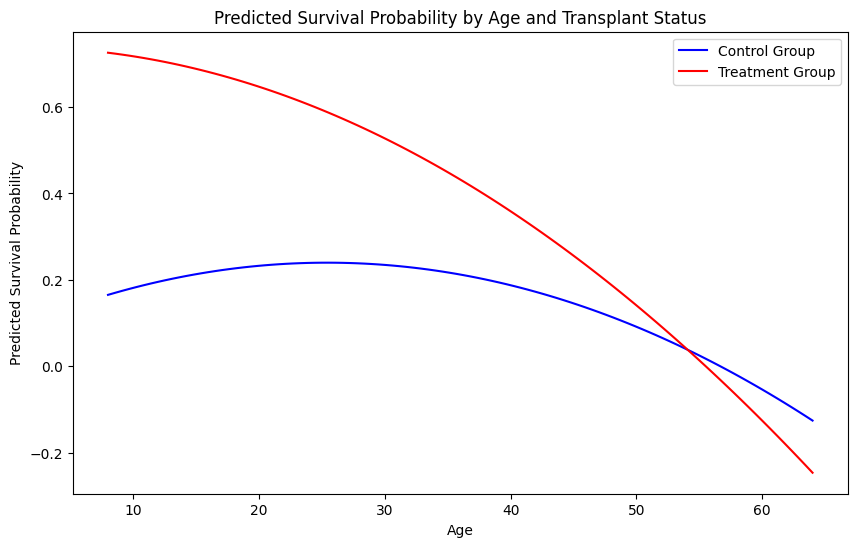

In [ ]:
#Pt 4
# Create a range of age values for prediction
age_range = np.linspace(heart['age'].min(), heart['age'].max(), 100)

# Create prediction dataframes for control and treatment groups
predict_control_df = pd.DataFrame({'age': age_range, 'transplant_treated': 0})
predict_treatment_df = pd.DataFrame({'age': age_range, 'transplant_treated': 1})

# Generate polynomial features for the prediction dataframes
predict_control_poly = poly.transform(predict_control_df)
predict_treatment_poly = poly.transform(predict_treatment_df)

# Convert back to DataFrame for easier handling and add column names
# Get the column names including the constant from the trained model's exog
trained_model_exog_names = X_train_poly_const.columns

predict_control_poly_df = pd.DataFrame(predict_control_poly, columns=poly_feature_names)
predict_treatment_poly_df = pd.DataFrame(predict_treatment_poly, columns=poly_feature_names)


#  Add a constant to the transformed prediction dataframes and ensure column order matches training data
predict_control_poly_const = sm.add_constant(predict_control_poly_df)
predict_treatment_poly_const = sm.add_constant(predict_treatment_poly_df)

# Reindex columns to match the training data's exog columns
predict_control_poly_const = predict_control_poly_const.reindex(columns=trained_model_exog_names, fill_value=0)
predict_treatment_poly_const = predict_treatment_poly_const.reindex(columns=trained_model_exog_names, fill_value=0)


#  Predict the survival probabilities for both groups
predicted_survival_control = results.predict(predict_control_poly_const)
predicted_survival_treatment = results.predict(predict_treatment_poly_const)

#  Plot the predicted survival probabilities
plt.figure(figsize=(10, 6))
plt.plot(age_range, predicted_survival_control, label='Control Group', color='blue')
plt.plot(age_range, predicted_survival_treatment, label='Treatment Group', color='red')

#  Label the axes and add a legend
plt.xlabel('Age')
plt.ylabel('Predicted Survival Probability')
plt.legend()

#  Add a title
plt.title('Predicted Survival Probability by Age and Transplant Status')

#  Display the plot
plt.show()


 Data Analysis Key Findings

*   The regression model was trained with polynomial features of degree 2 for age and transplant status, including an interaction term.
*   The model performance on the training set was R-squared of 0.1562 and RMSE of 0.4009.
*   The model performance on the test set was R-squared of 0.2329 and RMSE of 0.4129.

Insights or Next Steps

*   The R-squared values are relatively low, suggesting the model explains a limited amount of variance in survival probability. Further feature engineering or different model types might be beneficial.

**Pt 5**



##Concerns about how the model is built:

* **Bias in the data**: The historical data used to train the model might reflect existing biases in healthcare access and outcomes.
* **Limited features**: The model currently only includes age and transplant_treated. Survival from a transplant is influenced by many other factors, such as the patient's overall health, lifestyle, and genes.
* **Model performance**: As seen in the notebook, the R-squared values were relatively low, indicating that the model doesn't explain a large proportion of the variance in survival probability. Relying on a model with limited predictive power for such critical decisions can be risky.
* **Ethical considerations**: Using age as a primary factor in determining who gets a transplant raises questions about ageism.


##Concerns about how the model is deployed:

* **Fairness and equity**: How will the model ensure fairness across different demographic groups? Will it exacerbate existing health disparities?
* **Accountability**: Who is responsible when the model makes a decision that leads to a negative outcome? Is it the developers, the healthcare providers, or the institutions using the model?
* **Human vs model**: Will the model's recommendations be the sole determinant, or will there be human oversight and the ability to override the algorithm based on clinical judgment and individual circumstances?
* **Data privacy and security**: Sensitive patient data will be used to train and run the model. Ensuring the privacy and security of this data is essential.